# Classificazione con PySpark MLlib
### Dataset: `in-vehicle-coupon-recommendation.csv`

> **Obiettivo:** Costruire un modello predittivo di Machine Learning in Spark in grado di prevedere la probabilità che un guidatore accetti **(1)** o rifiuti **(0)** un coupon di sconto offerto durante la guida in base a diverse variabili, tra cui condizioni del viaggio, attributi del coupon e dati demografici e personali del guidatore.

### **0. Setup dell'ambiente**
La variabili d'ambiente vanno impostate ed eseguite prima che parta la JVM per prevenire errori che altrimenti compaiono più avanti.

In [2]:
import os
import sys
import shutil
from pathlib import Path

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

# Su Windows: decommenta e adatta se winutils non e' gia' nelle variabili di sistema
# os.environ["HADOOP_HOME"] = r"C:\hadoop"
# os.environ["PATH"] = os.environ["PATH"] + r";C:\hadoop\bin"

print("Interprete    :", sys.executable)
print("HADOOP_HOME   :", os.environ.get("HADOOP_HOME", "NON IMPOSTATO"))
print("SPARK_LOCAL_IP:", os.environ.get("SPARK_LOCAL_IP"))

Interprete    : C:\Users\Allysa\Documents\MachineLearning-in-Spark\.venv\Scripts\python.exe
HADOOP_HOME   : C:\hadoop
SPARK_LOCAL_IP: 127.0.0.1


### **1. Avvio di sessione Spark**
Inizializzazione della sessione Spark per il calcolo distribuito, configurando la memoria e le partizioni ottimali.

Esecuzione di un **smoke test** per verificareche il canale JVM driver <-> Python worker funzioni.

In [3]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("InVehicleCouponRecommendation")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "4")
    .config("spark.python.authenticate.socketTimeout", "60")
    .config("spark.driver.host", "127.0.0.1")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

print("Spark  :", spark.version)
print("Shuffle:", spark.conf.get("spark.sql.shuffle.partitions"))

Spark  : 4.2.0
Shuffle: 4


In [4]:
# Smoke test del canale JVM <-> Python worker
assert spark.sparkContext.parallelize([1, 2, 3]).map(lambda x: x * 2).collect() == [2, 4, 6]
print("Test Spark: Perfetto!")

Test Spark: Perfetto!


### **2. Caricamento del dataset**
Lettura del dataset e importazione all'interno di un DataFrame
`inferSchema=True`-> Spark leggerà il file due volte: una per analizzare il contenuto delle colonne e capire di che tipo sono, e secondo per il caricamento effettivo.

In [5]:
DATA_PATH = Path("data/in-vehicle-coupon-recommendation.csv")
if not DATA_PATH.exists():
     raise FileNotFoundError(f"File non esiste nel percorso specificato!")

In [6]:
df = spark.read.csv(str(DATA_PATH), header=True, inferSchema=True)
df.printSchema()

root
 |-- destination: string (nullable = true)
 |-- passanger: string (nullable = true)
 |-- weather: string (nullable = true)
 |-- temperature: integer (nullable = true)
 |-- time: string (nullable = true)
 |-- coupon: string (nullable = true)
 |-- expiration: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: string (nullable = true)
 |-- maritalStatus: string (nullable = true)
 |-- has_children: integer (nullable = true)
 |-- education: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- income: string (nullable = true)
 |-- car: string (nullable = true)
 |-- Bar: string (nullable = true)
 |-- CoffeeHouse: string (nullable = true)
 |-- CarryAway: string (nullable = true)
 |-- RestaurantLessThan20: string (nullable = true)
 |-- Restaurant20To50: string (nullable = true)
 |-- toCoupon_GEQ5min: integer (nullable = true)
 |-- toCoupon_GEQ15min: integer (nullable = true)
 |-- toCoupon_GEQ25min: integer (nullable = true)
 |-- direction_same: inte

In [7]:
from pyspark.sql.types import StructField, StructType, StringType, IntegerType

column_mapping = {
    "destination": StringType(), "passanger": StringType(), "weather": StringType(),
    "temperature" : IntegerType(), "time": StringType(), "coupon": StringType(),
    "expiration": StringType(), "gender": StringType(), "age": StringType(),
    "maritalStatus": StringType(), "has_children": IntegerType(),
    "education": StringType(), "occupation": StringType(), "income": StringType(),
    "car": StringType(), "Bar": StringType(), "CoffeeHouse": StringType(),
    "CarryAway": StringType(), "RestaurantLessThan20": StringType(),
    "Restaurant20To50": StringType(), "toCoupon_GEQ5min": IntegerType(),
    "toCoupon_GEQ15min": IntegerType(), "toCoupon_GEQ25min": IntegerType(),
    "direction_same": IntegerType(), "direction_opp": IntegerType(),
    "Y": IntegerType()
}

SCHEMA = StructType([
    StructField(name, dtype, True) for name, dtype in column_mapping.items()
])

df = spark.read.option("header", "true").csv(str(DATA_PATH), schema=SCHEMA).cache()
df.show(5)

+---------------+---------+-------+-----------+----+--------------------+----------+------+---+-----------------+------------+--------------------+----------+---------------+----+-----+-----------+---------+--------------------+----------------+----------------+-----------------+-----------------+--------------+-------------+---+
|    destination|passanger|weather|temperature|time|              coupon|expiration|gender|age|    maritalStatus|has_children|           education|occupation|         income| car|  Bar|CoffeeHouse|CarryAway|RestaurantLessThan20|Restaurant20To50|toCoupon_GEQ5min|toCoupon_GEQ15min|toCoupon_GEQ25min|direction_same|direction_opp|  Y|
+---------------+---------+-------+-----------+----+--------------------+----------+------+---+-----------------+------------+--------------------+----------+---------------+----+-----+-----------+---------+--------------------+----------------+----------------+-----------------+-----------------+--------------+-------------+---+
|No 

### **3. EDA - Exploratory Data Analysis**
Analisi dello schema e verifica delle statistiche descrittive.
> **NB:** Il nome convenzionale è `import python.sql.functions as F` per assicurare che vengano usate le funzioni Spark e non quelle native Python.

In [35]:
cat_cols = [
    "destination", "passanger", "weather", "time", "coupon", "expiration",
    "age", "gender", "maritalStatus", "education", "occupation", "income",
    "car", "Bar", "CoffeeHouse", "CarryAway",
    "RestaurantLessThan20", "Restaurant20To50"
]

num_cols = [
    "temperature",
    "has_children",
    "toCoupon_GEQ5min",
    "toCoupon_GEQ15min",
    "toCoupon_GEQ25min",
    "direction_same",
    "direction_opp"
]

print(f"Dimensioni: {df.count()} righe, {len(df.columns)} colonne\n")

print(f"Statistiche descrittive (colonne numeriche):")
df.select(num_cols).summary().show()

Dimensioni: 12684 righe, 27 colonne

Statistiche descrittive (colonne numeriche):
+-------+------------------+------------------+----------------+------------------+-------------------+-------------------+------------------+
|summary|       temperature|      has_children|toCoupon_GEQ5min| toCoupon_GEQ15min|  toCoupon_GEQ25min|     direction_same|     direction_opp|
+-------+------------------+------------------+----------------+------------------+-------------------+-------------------+------------------+
|  count|             12684|             12684|           12684|             12684|              12684|              12684|             12684|
|   mean|63.301797540208135|0.4141438032166509|             1.0|0.5614947965941344|0.11912645853043204|0.21475875118259224|0.7852412488174078|
| stddev| 19.15448575684057|   0.4925929797555|             0.0|0.4962235416149696| 0.3239500256352576|  0.410671068264036| 0.410671068264036|
|    min|                30|                 0|             

In [28]:
import pyspark.sql.functions as F

for c in ["coupon", "destination", "time", "expiration"]:
    print(f"Frequenze: {c}")
    df.groupBy(c).count().orderBy(F.desc("count")).show()

Frequenze: coupon
+--------------------+-----+
|              coupon|count|
+--------------------+-----+
|        Coffee House| 3996|
|     Restaurant(<20)| 2786|
|Carry out & Take ...| 2393|
|                 Bar| 2017|
|   Restaurant(20-50)| 1492|
+--------------------+-----+

Frequenze: destination
+---------------+-----+
|    destination|count|
+---------------+-----+
|No Urgent Place| 6283|
|           Home| 3237|
|           Work| 3164|
+---------------+-----+

Frequenze: time
+----+-----+
|time|count|
+----+-----+
| 6PM| 3230|
| 7AM| 3164|
|10AM| 2275|
| 2PM| 2009|
|10PM| 2006|
+----+-----+

Frequenze: expiration
+----------+-----+
|expiration|count|
+----------+-----+
|        1d| 7091|
|        2h| 5593|
+----------+-----+



+---+-----+-----------+
|  Y|count|percentuale|
+---+-----+-----------+
|  1| 7210|      56.84|
|  0| 5474|      43.16|
+---+-----+-----------+



C:\Users\Allysa\Documents\MachineLearning-in-Spark\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [UNSUPPORTED_PACKAGE_VERSION] PyArrow >= 18.0.0 must be installed; however, your version is 16.1.0.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


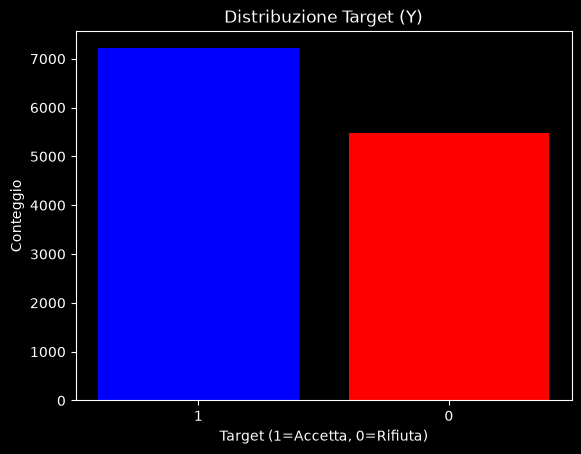

In [55]:
#Distribuzione target percentuale e grafico
import pandas as pd
import matplotlib.pyplot as plt

total_row = df.count()
df.groupBy("Y").count().withColumn("percentuale", F.round(F.col("count")/total_row * 100,2)).show()

target_pd = df.groupBy("Y").count().toPandas()
plt.bar(target_pd['Y'].astype(str), target_pd['count'], color=['blue', 'red'])
plt.title('Distribuzione Target (Y)')
plt.xlabel("Target (1=Accetta, 0=Rifiuta)")
plt.ylabel("Conteggio")
plt.show()


### **4. Data Cleaning**
Comprende il conteggio ed eventuale rimuozione dei duplicati, eliminazione delle colonne inutilizzabili o costanti e verifica dei valori nulli.

In [60]:
null_counts = df.select(
    [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns]
).toPandas().T

C:\Users\Allysa\Documents\MachineLearning-in-Spark\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [UNSUPPORTED_PACKAGE_VERSION] PyArrow >= 18.0.0 must be installed; however, your version is 16.1.0.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


In [9]:
after_removal_total = df.dropDuplicates().count()

print(f"Numero totale di righe: {total_rows}")
print(f"Numero totale di righe dopo rimuozione duplicati: {after_removal_total}")

Numero totale di righe: 12684
Numero totale di righe dopo rimuozione duplicati: 12610


### **4. Pre-processing con MLlib**
Comprende la **pulizia** (gestione dei valori mancanti e sbagliati e rimozione dei duplicati), **la conversione** (trasformazione delle variabili categoriche e assemblaggio di un vettore unico con `VectorAssembler` e preparazione del target.

> **NB:** La colonna `age` viene trattata come categorica perché nel dataset reale compare anche il valore `50plus`, quindi non è una variabile numerica pura.

In [10]:
target = "Y"

colonne_categoriche = [
    "destination", "passanger", "weather", "time", "coupon", "expiration",
    "age", "gender", "maritalStatus", "education", "occupation", "income",
    "car", "Bar", "CoffeeHouse", "CarryAway",
    "RestaurantLessThan20", "Restaurant20To50"
]

colonne_numeriche = [
    "temperature",
    "has_children",
    "toCoupon_GEQ5min",
    "toCoupon_GEQ15min",
    "toCoupon_GEQ25min",
    "direction_same",
    "direction_opp"
]

controllo_colonne = colonne_categoriche + colonne_numeriche + [target]
colonne_missing = [c for c in controllo_colonne if c not in df.columns]
if colonne_missing:
    raise ValueError(f"Colonne mancanti nel dataset: {colonne_missing}")


In [11]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler

indexer = [StringIndexer(
    inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in colonne_categoriche]

encoder = [OneHotEncoder(
    inputCol=c + "_idx", outputCol=c + "_vec")
    for c in colonne_categoriche]

assembler = VectorAssembler(
    inputCols=[c + "_vec" for c in colonne_categoriche] + colonne_numeriche,
    outputCol="features_unscaled"
)

scaler = StandardScaler(inputCol="features_unscaled", outputCol="features", withStd=True, withMean=True)

df = df.withColumn("label", F.col(target).cast("double"))

In [12]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)
print(f"Train set: {train_df.count()} righe")
print(f"Test set: {test_df.count()} righe")


Train set: 10193 righe
Test set: 2491 righe


### **5. Addestramento del modello**
Per avere un termine di paragone base (baseline), si addestra un primo modello di classificazione lineare tramite la `LinearRegression`.
 Successivamente si addestra un altro modello più avanzato con `RandomForest` per catturare le relazioni complesse e non lineari.
Infine, si fa un confronto tra i due modelli per stabilire quale algoritmo sia più adatto al problema.

In [13]:
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

lr = LogisticRegression(featuresCol="features", labelCol="label")
rf = RandomForestClassifier(featuresCol="features", labelCol="label", seed=42)

pipeline_stages = indexer + encoder + [assembler, scaler]

pipeline_lr = Pipeline(stages=pipeline_stages + [lr])
pipeline_rf = Pipeline(stages=pipeline_stages + [rf])

model_lr = pipeline_lr.fit(train_df)
model_rf = pipeline_rf.fit(train_df)

preds_lr = model_lr.transform(test_df)
preds_rf = model_rf.transform(test_df)

eval_roc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
eval_pr = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderPR")
eval_acc = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
eval_f1 = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

def get_metrics(preds):
    return {
        "ROC AUC": eval_roc.evaluate(preds),
        "PR AUC": eval_pr.evaluate(preds),
        "Accuracy": eval_acc.evaluate(preds),
        "F1": eval_f1.evaluate(preds)
    }

metrics_df = pd.DataFrame([get_metrics(preds_lr), get_metrics(preds_rf)],
                          index=["Logistic Regression", "Random Forest"])
print(metrics_df)


                      ROC AUC    PR AUC  Accuracy        F1
Logistic Regression  0.749669  0.781875  0.697310  0.693187
Random Forest        0.765838  0.782391  0.690486  0.666088


### **6. Tuning con Cross validation**
Per trovare i parametri perfetti senza rischiare l'overfitting, si testano diverse combinazioni di iperparametri tramite validazione incrociata.

In [14]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

binary_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    metricName="areaUnderROC")

rf_tuned = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    seed=42)

pipeline_tuned = Pipeline(
    stages=indexer + encoder + [assembler, scaler, rf_tuned])

param_grid = (
    ParamGridBuilder()
    .addGrid(rf_tuned.numTrees, [30, 60])
    .addGrid(rf_tuned.maxDepth, [5, 8])
    .build())

cross_validator = CrossValidator(
    estimator=pipeline_tuned,
    estimatorParamMaps=param_grid,
    evaluator=binary_evaluator,
    numFolds=3,
    parallelism=2)

print(f"Numero totale di combinazioni: {len(param_grid)}")

cv_model = cross_validator.fit(train_df)
cv_predictions = cv_model.transform(test_df)
auc_cv = binary_evaluator.evaluate(cv_predictions)

best_rf = cv_model.bestModel.stages[-1]
print(f"Migliori Parametri: numTrees={best_rf.getNumTrees}, maxDepth={best_rf.getOrDefault('maxDepth')}")

print(f"AUC dopo Cross Validation: {auc_cv:.4f}")


Numero totale di combinazioni: 4
Migliori Parametri: numTrees=60, maxDepth=8
AUC dopo Cross Validation: 0.7912


### **7. Analisi delle Feature Importance**
Interrogare il modello finale per estrarre il peso decisionale di ogni feature, costruendo un grafico a barre per mostrare le più influenti.

In [15]:
best_model = cv_model.bestModel
rf_model = best_model.stages[-1]

transformed_df = best_model.transform(train_df)

feature_metadata = transformed_df.schema["features"].metadata["ml_attr"]["attrs"]

feature_names = {}
for attr_type in feature_metadata:
    for attr in feature_metadata[attr_type]:
        feature_names[attr["idx"]] = attr["name"]

importances = rf_model.featureImportances.toArray()

feature_imp_df = pd.DataFrame({
    "Index": list(feature_names.keys()),
    "Feature_Name": list(feature_names.values()),
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_imp_df.head(5).to_string(index=False))

top_features = feature_imp_df.head(15).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature_Name"], top_features["Importance"], color="skyblue")
plt.xlabel("Importanza Relativa")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - Random Forest (Nomi Reali)")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

KeyError: 'attrs'

In [ ]:
#spark.stop()